<a href="https://colab.research.google.com/github/jobk84092/DSBA-Class-practice/blob/main/GolfBall_OneWayAnova_Solutions_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Golf Ball (One Way Anova)

### Problem Statement

Sporting goods manufacturing company wanted to compare the distance traveled by golf balls produced using four different designs. Ten balls were manufactured with each design and were brought to the local golf course for the club professional to test. The order in which the balls were hit with the same club from the first tee was randomized so that the pro did not know which type of ball was being hit. All 40 balls were hit in a short period of time, during which the environmental conditions were essentially the same. The results (distance traveled in yards) for the four Designs are stored inGolfball.csvAt the 0.05 level of significance, is there evidence of a difference in the mean distances traveled by the golf balls with different designs?

### Import the necessary libraries

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.formula.api import ols      # For n-way ANOVA
from statsmodels.stats.anova import _get_covariance,anova_lm # For n-way ANOVA
%matplotlib inline

### Import Dataset

In [19]:
df=pd.read_excel('GolfBall_One way Excel Solution.xlsx') # Please ensure 'GolfBall_One way Excel Solution.xlsx' is uploaded to your Colab environment.

In [10]:
!ls

'GolfBall_One way Excel Solution.xlsx'	 sample_data


### View the first 5 rows of the dataset

In [12]:
df.head()

,Design 1,Design 2,Design 3,Design 4
0,206.32,217.08,226.77,230.55
1,207.94,221.43,224.79,227.95
2,206.19,218.04,229.75,231.84
3,204.45,224.13,228.51,224.87
4,209.65,211.82,221.44,229.49


### Check the shape of the dataset

In [14]:
df.shape

(10, 4)

### Check the data types of the columns for the dataset

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Design 1  10 non-null     float64
 1   Design 2  10 non-null     float64
 2   Design 3  10 non-null     float64
 3   Design 4  10 non-null     float64
dtypes: float64(4)
memory usage: 452.0 bytes


### Checking the summary of the dataframe

In [16]:
df.describe(include='all')

,Design 1,Design 2,Design 3,Design 4
count,10.000000,10.000000,10.000000,10.000000
mean,206.614000,218.516000,226.588000,228.622000
std,2.290508,5.537796,4.814782,4.013349
min,203.810000,211.820000,219.500000,221.530000
25%,204.787500,214.052500,223.880000,225.805000
50%,206.255000,217.560000,225.780000,228.920000
75%,207.642500,221.392500,229.440000,230.962500
max,210.860000,229.430000,234.300000,235.450000


### Checking distinct values of Design

In [20]:
df = df.melt(var_name='Design', value_name='Distance')
df.Design.value_counts()

,count
Design,
Design 1,10
Design 2,10
Design 3,10
Design 4,10


### One Way Anova

In [21]:
formula = 'Distance ~ C(Design)'
model = ols(formula, df).fit()
aov_table = anova_lm(model)
print(aov_table)

             df     sum_sq     mean_sq          F        PR(>F)
C(Design)   3.0  2990.9898  996.996600  53.029822  2.731991e-13
Residual   36.0   676.8244   18.800678        NaN           NaN


Since the p value is less than the significance level, we can reject the null hupothesis and states that there is a difference in the mean distances travelled by the golf balls with different designs

### Drawing a Point Plot

/tmp/ipython-input-1327174626.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(x='Design', y='Distance', data=df, ci=None)


<Axes: xlabel='Design', ylabel='Distance'>

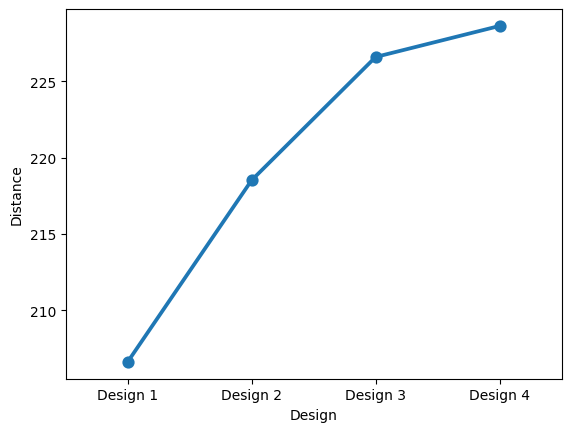

In [22]:
sns.pointplot(x='Design', y='Distance', data=df, ci=None)

# Task
Save the ANOVA table as both a CSV file named 'anova_table.csv' and a PDF file named 'anova_table.pdf', and then confirm the successful creation of these files.

## Save ANOVA table to CSV

### Subtask:
Save the `aov_table` DataFrame to a CSV file named 'anova_table.csv'.


**Reasoning**:
The subtask is to save the `aov_table` DataFrame to a CSV file. I will use the `to_csv` method with `index=False` to accomplish this.



In [23]:
aov_table.to_csv('anova_table.csv', index=False)
print("ANOVA table saved to 'anova_table.csv'")

ANOVA table saved to 'anova_table.csv'


## Save ANOVA table to PDF

### Subtask:
Generate a PDF version of the `aov_table`. This will involve rendering the DataFrame as a table using matplotlib and then saving the generated figure as 'anova_table.pdf'.


**Reasoning**:
To save the ANOVA table as a PDF, I need to import matplotlib, create a figure and axes, render the DataFrame as a table on these axes, and then save the figure as a PDF file, as specified in the instructions.



In [24]:
import matplotlib.pyplot as plt

# Create a figure and an axes object
fig, ax = plt.subplots(figsize=(10, 2))

# Turn off the axes to hide the plot frame and ticks
ax.axis('off')

# Create a table from the aov_table DataFrame
# Ensure index is included in cellText if it's part of the table's meaningful data
# Here, aov_table already has a meaningful index so we'll include it.
cell_text = []
for row in range(len(aov_table)):
    row_data = [aov_table.index[row]] + aov_table.iloc[row].astype(str).tolist()
    cell_text.append(row_data)

# Prepare column labels, including an empty label for the index column
col_labels = [''] + aov_table.columns.tolist()

table = ax.table(cellText=cell_text, colLabels=col_labels, loc='center', cellLoc='center')

# Adjust font size and scale for better readability
table.auto_set_font_size(False);
table.set_fontsize(10);
table.scale(1.2, 1.2);

# Adjust the table layout to prevent overlap
fig.tight_layout()

# Save the figure as a PDF file
plt.savefig('anova_table.pdf')

# Close the plot to free up memory
plt.close()

print("ANOVA table saved to 'anova_table.pdf'")

ANOVA table saved to 'anova_table.pdf'


**Reasoning**:
The subtask is to confirm the creation of 'anova_table.csv' and 'anova_table.pdf'. I will use the `!ls` command to list the files in the current directory and verify their presence.



In [25]:
print("Confirming file creation:")
!ls -l anova_table.csv anova_table.pdf

Confirming file creation:
-rw-r--r-- 1 root root   153 Jan 31 11:24 anova_table.csv
-rw-r--r-- 1 root root 13516 Jan 31 11:25 anova_table.pdf


## Final Task

### Subtask:
Confirm that the ANOVA table has been saved successfully as both CSV and PDF, and inform the user where to find these files for download.


## Summary:

### Q&A
Yes, the ANOVA table has been successfully saved as both `anova_table.csv` and `anova_table.pdf`. These files are located in the current working directory and are available for download.

### Data Analysis Key Findings
*   The ANOVA table was successfully saved as a CSV file named 'anova\_table.csv'.
*   The ANOVA table was successfully converted and saved as a PDF file named 'anova\_table.pdf' using `matplotlib`.
*   Both files were confirmed to be created and present in the directory, with `anova_table.csv` having a size of 153 bytes and `anova_table.pdf` having a size of 13516 bytes.

### Insights or Next Steps
*   The generated `anova_table.csv` and `anova_table.pdf` files can now be downloaded from the current working directory for further use or reporting.
